# What does BeliefLens find that raw prompting conceals?

## A frozen SPY/SGOV measurement and governance case study

This notebook compares four observable channels for the same evidence: the **generated categorical response**, **printed probabilities**, **raw continuation probabilities**, and **BeliefLens calibrated state probabilities**. The reference is a frozen categorical market-state response, not an unknowable “true belief probability.”

All results are archived: **zero provider calls**.

> **Question:** When an AI answer sounds decisive, do its language probabilities support it—and is the discrepancy large enough to justify intervention?

In [1]:
from pathlib import Path
import json, textwrap, numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
COLORS={'Risk-on':'#159570','Mixed':'#D29A21','Risk-off':'#C85050','Unsure':'#6B7280'}
def locate():
    for b in [Path.cwd(),*Path.cwd().parents]:
        if (b/'examples/notebooks/finance/data/offline_reproduction/row_level_measurements.csv').exists(): return b
    raise FileNotFoundError('Run from the reproducibility repository.')
REPO=locate(); DATA=REPO/'examples/notebooks/finance/data/offline_reproduction'
FIG=REPO/'examples/notebooks/finance/assets/spy_governance_story'; FIG.mkdir(parents=True,exist_ok=True)
d=pd.read_csv(DATA/'row_level_measurements.csv',parse_dates=['date'])
result=json.loads((DATA/'API_REPRODUCTION_RESULT.json').read_text())
records=[json.loads(line) for line in (DATA/'inputs/records.jsonl').read_text().splitlines() if line.strip()]
evidence_by_id={row['observation_id']:row['evidence_text'] for row in records}
variation=json.loads((DATA/'prompt_variation_example.json').read_text())
prices=pd.read_csv(DATA/'inputs/prices_total_return.csv',index_col=0,parse_dates=True)
test=d[d.partition.eq('test')].copy().sort_values('date').reset_index(drop=True)
STATES=['Risk-on','Mixed','Risk-off']
print(f'Archived: {len(d)}; untouched test: {len(test)}; provider calls: 0')

Archived: 412; untouched test: 127; provider calls: 0


## 1. Same evidence, four channels

The generated response is a constrained classifier. Printed probabilities are generated numbers. Continuation probabilities come from model-native token probabilities. BeliefLens calibrates the continuation vector. The example is selected solely for the largest printed–calibrated disagreement in the untouched test set—not for its return.

/var/folders/xj/47dwgr1d5jd7l2rygr10vjxr0000gp/T/ipykernel_91938/2674769502.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(FIG/'01_four_channels.png',dpi=180,bbox_inches='tight'); plt.show()


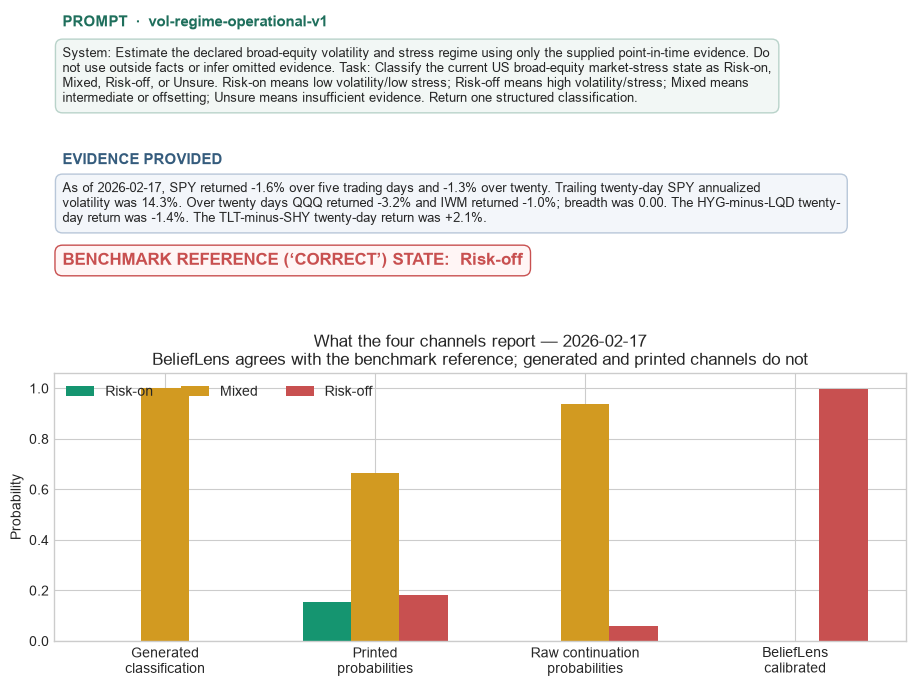

,Risk-on,Mixed,Risk-off
Generated,0.000,1.000,0.000
Printed,0.153,0.663,0.184
Raw continuation,0.000,0.940,0.060
BeliefLens calibrated,0.000,0.001,0.999


In [2]:
def norm(x):
    x=np.asarray(x,float); return x/x.sum(axis=1,keepdims=True)
def js1(a,b):
    m=.5*(a+b); return .5*np.sum(a*np.log(np.maximum(a,1e-15)/np.maximum(m,1e-15)),axis=1)+.5*np.sum(b*np.log(np.maximum(b,1e-15)/np.maximum(m,1e-15)),axis=1)
raw4=test[['raw_risk_on','raw_mixed','raw_risk_off','raw_unsure']].to_numpy()
raw3=norm(raw4[:,:3]); printed=norm(test[['elicited_risk_on','elicited_mixed','elicited_risk_off']])
calibrated=norm(test[['calibrated_risk_on','calibrated_mixed','calibrated_risk_off']])
test['printed_calibrated_js']=js1(printed,calibrated); i=int(test.printed_calibrated_js.to_numpy().argmax()); r=test.iloc[i]
direct=np.zeros(3)
if int(r.direct_choice_index)<3: direct[int(r.direct_choice_index)]=1
v=np.vstack([direct,printed[i],raw3[i],calibrated[i]])
evidence=evidence_by_id[r.scenario_id]
prompt=("System: Estimate the declared broad-equity volatility and stress regime using only the supplied point-in-time evidence. "
        "Do not use outside facts or infer omitted evidence. Task: Classify the current US broad-equity market-stress state as "
        "Risk-on, Mixed, Risk-off, or Unsure. Risk-on means low volatility/low stress; Risk-off means high volatility/stress; "
        "Mixed means intermediate or offsetting; Unsure means insufficient evidence. Return one structured classification.")
fig=plt.figure(figsize=(11,8.2)); gs=fig.add_gridspec(2,1,height_ratios=[1.05,1],hspace=.30)
top=fig.add_subplot(gs[0]); ax=fig.add_subplot(gs[1]); top.axis('off')
top.text(.01,.98,'PROMPT  ·  vol-regime-operational-v1',va='top',fontsize=11,fontweight='bold',color='#1F6F5C')
top.text(.01,.87,textwrap.fill(prompt,125),va='top',fontsize=9.2,bbox=dict(boxstyle='round,pad=.55',facecolor='#F2F7F5',edgecolor='#B9D3CA'))
top.text(.01,.49,'EVIDENCE PROVIDED',va='top',fontsize=11,fontweight='bold',color='#355C7D')
top.text(.01,.39,textwrap.fill(evidence,125),va='top',fontsize=9.2,bbox=dict(boxstyle='round,pad=.55',facecolor='#F3F6FA',edgecolor='#B8C7D9'))
top.text(.01,.08,f"BENCHMARK REFERENCE (‘CORRECT’) STATE:  {r.external_regime}",va='bottom',fontsize=12,fontweight='bold',color=COLORS[r.external_regime],bbox=dict(boxstyle='round,pad=.45',facecolor='#FFF5F5',edgecolor=COLORS[r.external_regime]))
x=np.arange(4); w=.23
for k,s in enumerate(STATES): ax.bar(x+(k-1)*w,v[:,k],w,label=s,color=COLORS[s])
ax.set(xticks=x,xticklabels=['Generated\nclassification','Printed\nprobabilities','Raw continuation\nprobabilities','BeliefLens\ncalibrated'],ylim=(0,1.06),ylabel='Probability')
ax.legend(ncol=3); ax.set_title(f'What the four channels report — {r.date.date()}\nBeliefLens agrees with the benchmark reference; generated and printed channels do not')
fig.tight_layout(); fig.savefig(FIG/'01_four_channels.png',dpi=180,bbox_inches='tight'); plt.show()
pd.DataFrame(v,index=['Generated','Printed','Raw continuation','BeliefLens calibrated'],columns=STATES).round(3)

## Historical evidence and prompt wording: a three-figure demonstration

The LLM was not shown a chart. Point-in-time historical series were transformed into the numerical five- and twenty-day summaries shown in the prompt. The first figure makes that data-generating step visible. The next two figures hold the evidence and task fixed while changing only the information-equivalent wording and order.

The system instruction **“do not use external facts” is an experimental control only**. It isolates the effect of the supplied point-in-time evidence and prompt presentation; it is not a recommendation that a deployed system ignore relevant external information.

The example below was selected because the raw modal classification changes across the three archived prompts while the frozen calibration map returns the same modal state. No new model calls were made.

/var/folders/xj/47dwgr1d5jd7l2rygr10vjxr0000gp/T/ipykernel_91938/1698935481.py:9: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(); fig.savefig(FIG/'01c_historical_evidence.png',dpi=180,bbox_inches='tight'); plt.show()


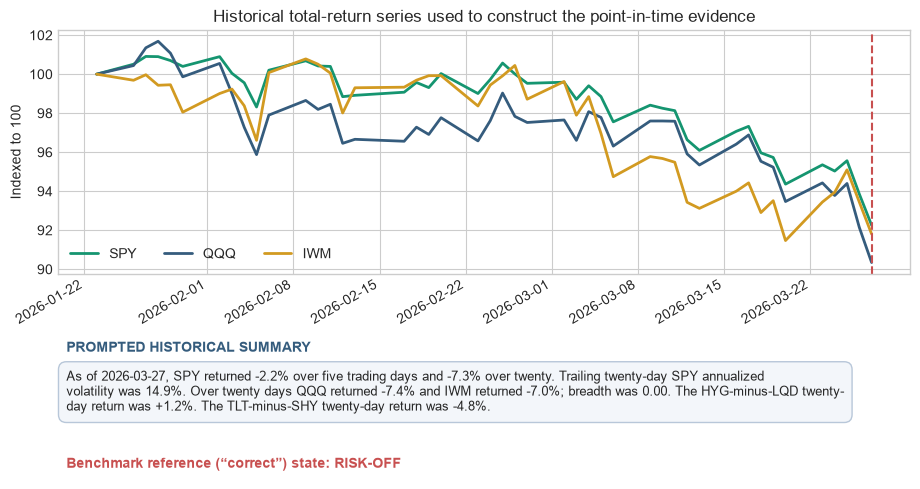

In [3]:
sid=variation['scenario_id']; day=pd.Timestamp(sid.replace('daily-','')); window=prices.loc[:day].tail(45)
indexed=window[['SPY','QQQ','IWM']]/window[['SPY','QQQ','IWM']].iloc[0]*100
fig=plt.figure(figsize=(11,6.6)); gs=fig.add_gridspec(2,1,height_ratios=[1.25,.72],hspace=.34)
ax0=fig.add_subplot(gs[0]); indexed.plot(ax=ax0,color=[COLORS['Risk-on'],'#355C7D',COLORS['Mixed']],lw=2)
ax0.axvline(day,color=COLORS['Risk-off'],ls='--'); ax0.set(title='Historical total-return series used to construct the point-in-time evidence',ylabel='Indexed to 100',xlabel=''); ax0.legend(ncol=3)
ax1=fig.add_subplot(gs[1]); ax1.axis('off'); ax1.text(.01,.98,'PROMPTED HISTORICAL SUMMARY',va='top',fontweight='bold',color='#355C7D')
ax1.text(.01,.78,textwrap.fill(variation['evidence'],125),va='top',fontsize=9.5,bbox=dict(boxstyle='round,pad=.6',facecolor='#F3F6FA',edgecolor='#B8C7D9'))
ax1.text(.01,.08,'Benchmark reference (“correct”) state: RISK-OFF',fontweight='bold',color=COLORS['Risk-off'])
fig.tight_layout(); fig.savefig(FIG/'01c_historical_evidence.png',dpi=180,bbox_inches='tight'); plt.show()

### Raw AI classification under information-equivalent prompts

The evidence, target, horizon, model snapshot and permitted responses are identical. Only the order and wording change. This is the instability that a single polished response conceals.

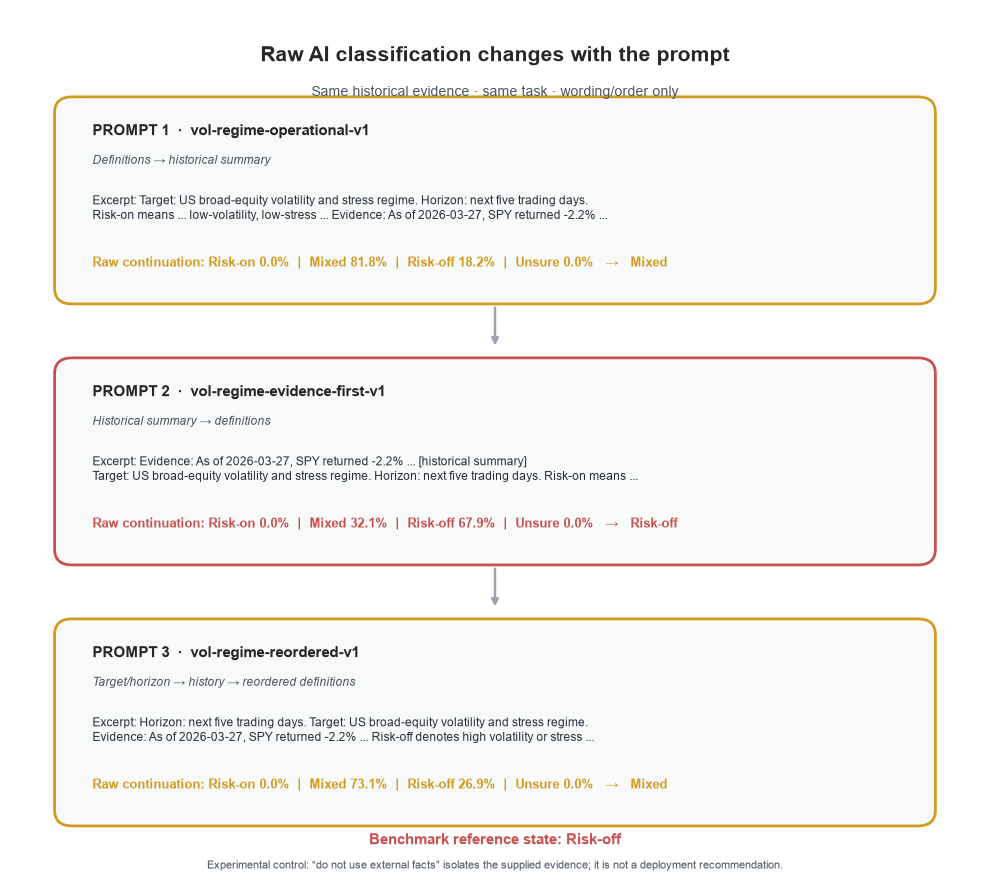

In [4]:
from matplotlib.patches import FancyBboxPatch
def prompt_sequence(probabilities,modal_states,title,filename,calibrated_view=False):
    fig,ax=plt.subplots(figsize=(10,9)); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ys=[.78,.48,.18]
    for idx,(pid,structure,excerpt,p,state,y) in enumerate(zip(variation['prompt_ids'],variation['prompt_structures'],variation['prompt_excerpts'],probabilities,modal_states,ys)):
        color=COLORS[state]; box=FancyBboxPatch((.06,y-.105),.88,.21,boxstyle='round,pad=.014,rounding_size=.018',facecolor='#F8FAF9',edgecolor=color,linewidth=2)
        ax.add_patch(box); ax.text(.085,y+.075,f'PROMPT {idx+1}  ·  {pid}',fontweight='bold',fontsize=10.5)
        ax.text(.085,y+.042,structure,fontsize=8.5,color='#4B5563',fontstyle='italic')
        ax.text(.085,y+.008,'Excerpt: '+excerpt,fontsize=8.3,color='#25313D',va='top',linespacing=1.35)
        if calibrated_view:
            txt=f"Calibrated: Risk-on {p[0]:.1%}  |  Mixed {p[1]:.1%}  |  Risk-off {p[2]:.1%}   →   {state}"
        else:
            txt=f"Raw continuation: Risk-on {p[0]:.1%}  |  Mixed {p[1]:.1%}  |  Risk-off {p[2]:.1%}  |  Unsure {p[3]:.1%}   →   {state}"
        ax.text(.085,y-.076,txt,fontsize=9.1,fontweight='bold',color=color)
        if idx<2: ax.annotate('',xy=(.5,y-.17),xytext=(.5,y-.12),arrowprops=dict(arrowstyle='-|>',color='#9CA3AF',lw=1.8))
    ax.text(.5,.94,title,ha='center',fontsize=15,fontweight='bold'); ax.text(.5,.90,'Same historical evidence · same task · wording/order only',ha='center',fontsize=10,color='#4B5563')
    ax.text(.5,.04,f"Benchmark reference state: {variation['reference_state']}",ha='center',fontsize=11,fontweight='bold',color=COLORS[variation['reference_state']])
    ax.text(.5,.012,'Experimental control: “do not use external facts” isolates the supplied evidence; it is not a deployment recommendation.',ha='center',fontsize=7.6,color='#4B5563')
    fig.tight_layout(); fig.savefig(FIG/filename,dpi=180,bbox_inches='tight'); plt.show()
prompt_sequence(variation['raw_probabilities'],variation['raw_modal_states'],'Raw AI classification changes with the prompt','01d_raw_prompt_instability.png')

### The same prompts after frozen BeliefLens calibration

The calibration map acts on the complete continuation vector, not merely the winning classification. In this selected case it produces the same Risk-off state under all three prompts, matching the benchmark reference. This is evidence of local prompt stability—not a universal invariance guarantee.

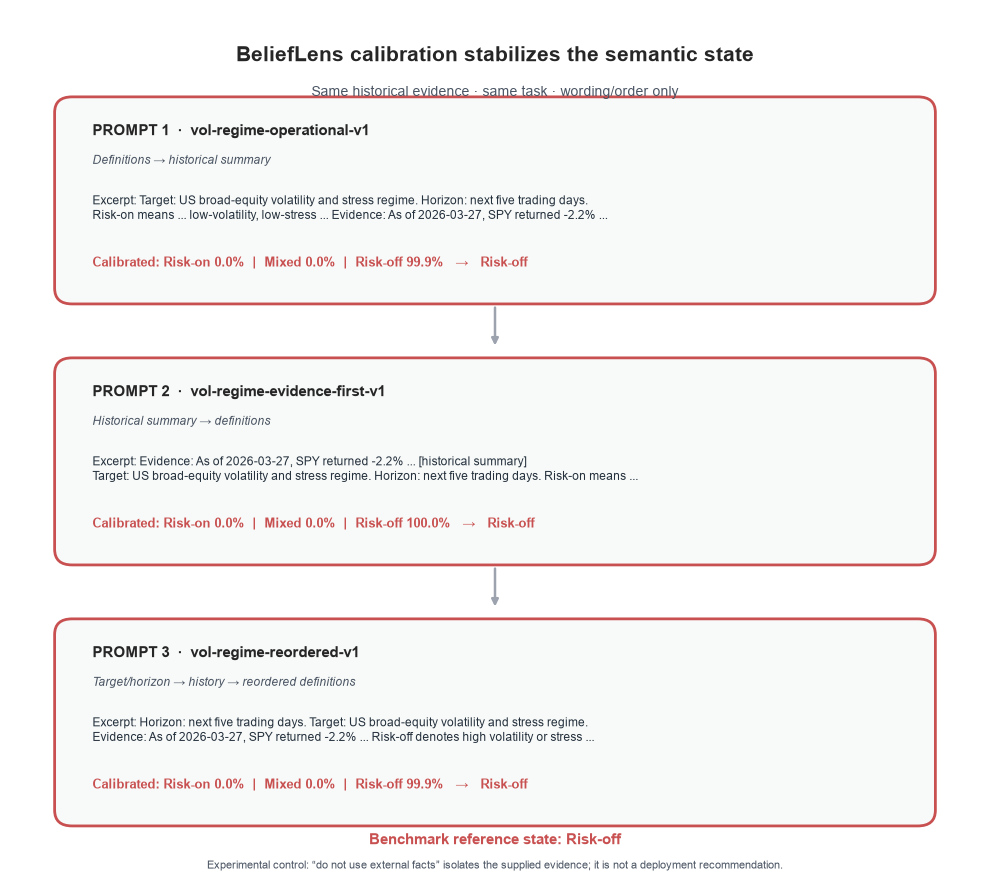

In [5]:
prompt_sequence(variation['calibrated_probabilities'],variation['calibrated_modal_states'],'BeliefLens calibration stabilizes the semantic state','01e_calibrated_prompt_stability.png',calibrated_view=True)

## 2. Printed confidence is not calibrated semantic probability

Each panel compares the printed probability with BeliefLens for one state. **Colored points** are observations whose benchmark reference equals that panel's state; **grey points** have another benchmark reference state. Points away from the diagonal expose channel discrepancy across the full untouched sample.

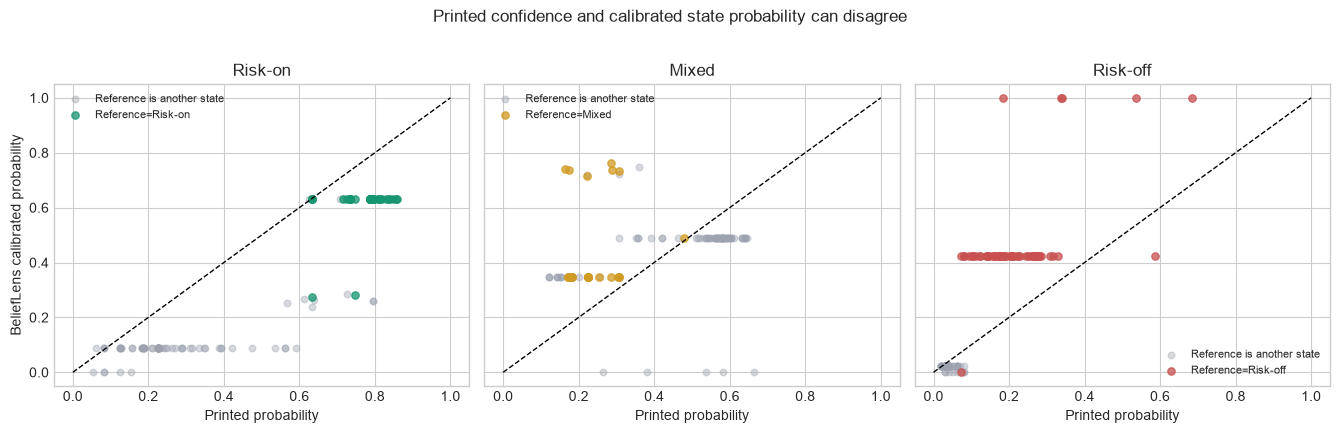

,mean absolute discrepancy
Risk-on,0.164
Mixed,0.156
Risk-off,0.145


In [6]:
ref=test.reference_state_index.to_numpy(int)
fig,axs=plt.subplots(1,3,figsize=(13.5,4.2),sharex=True,sharey=True)
for k,(ax,s) in enumerate(zip(axs,STATES)):
    hit=ref==k; ax.scatter(printed[~hit,k],calibrated[~hit,k],s=22,alpha=.4,color='#9CA3AF',label='Reference is another state')
    ax.scatter(printed[hit,k],calibrated[hit,k],s=28,alpha=.75,color=COLORS[s],label=f'Reference={s}')
    ax.plot([0,1],[0,1],'k--',lw=1); ax.set(title=s,xlabel='Printed probability'); ax.legend(fontsize=8)
axs[0].set_ylabel('BeliefLens calibrated probability')
fig.suptitle('Printed confidence and calibrated state probability can disagree',y=1.02)
fig.tight_layout(); fig.savefig(FIG/'02_printed_vs_calibrated.png',dpi=180,bbox_inches='tight'); plt.show()
pd.DataFrame({'mean absolute discrepancy':[np.mean(abs(printed[:,k]-calibrated[:,k])) for k in range(3)]},index=STATES).round(3)

## 3. Does calibration improve agreement with the reference response?

The frozen benchmark supplies a categorical reference response, not a reference posterior probability vector. The primary held-out comparison is therefore categorical: whether each channel's modal state agrees with the benchmark. We report overall accuracy and response-specific recall. Confidence is retained only as a secondary diagnostic showing how strongly each channel supports its own selected state when that selection is correct or incorrect; it is not interpreted as absolute posterior error.

The frozen conformal procedure is assessed separately: empirical coverage is 113/127 = 88.98% against a nominal 90%.

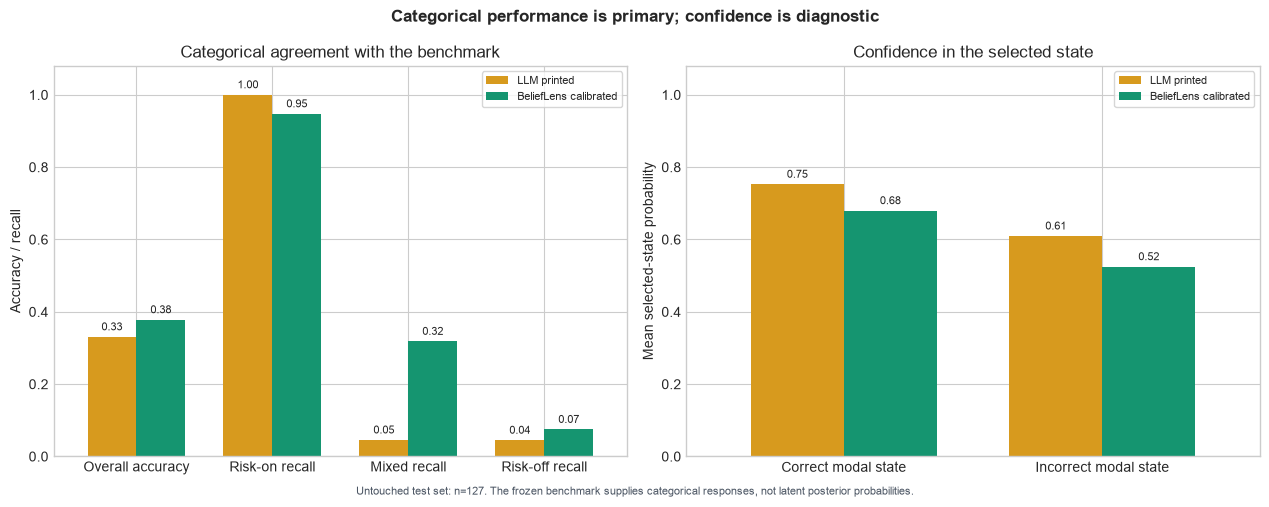

,LLM printed,BeliefLens calibrated
Overall accuracy,0.331,0.378
Risk-on recall,1.000,0.947
Mixed recall,0.045,0.318
Risk-off recall,0.045,0.075


,LLM printed,BeliefLens calibrated
Correct modal state,0.753,0.680
Incorrect modal state,0.609,0.525


In [7]:
def js(a,b):
    m=.5*(a+b)
    return .5*np.sum(a*np.log(np.maximum(a,1e-15)/np.maximum(m,1e-15)))+.5*np.sum(b*np.log(np.maximum(b,1e-15)/np.maximum(m,1e-15)))
radius=float(result['measurement_diagnostics']['conformal_coverage']['radius_js'])
printed_class=np.argmax(printed,axis=1); calibrated_class=np.argmax(calibrated,axis=1)
printed_correct=printed_class==ref; calibrated_correct=calibrated_class==ref
accuracy_table=pd.DataFrame({
    'LLM printed': [printed_correct.mean()]+[(printed_class[ref==k]==k).mean() for k in range(3)],
    'BeliefLens calibrated': [calibrated_correct.mean()]+[(calibrated_class[ref==k]==k).mean() for k in range(3)],
},index=['Overall accuracy']+[f'{state} recall' for state in STATES])
printed_confidence=printed.max(axis=1); calibrated_confidence=calibrated.max(axis=1)
confidence_table=pd.DataFrame({
    'LLM printed':[printed_confidence[printed_correct].mean(),printed_confidence[~printed_correct].mean()],
    'BeliefLens calibrated':[calibrated_confidence[calibrated_correct].mean(),calibrated_confidence[~calibrated_correct].mean()],
},index=['Correct modal state','Incorrect modal state'])
fig,axs=plt.subplots(1,2,figsize=(12.8,4.9))
accuracy_table.plot.bar(ax=axs[0],color=['#D79A1E','#159570'],width=.72)
axs[0].set(title='Categorical agreement with the benchmark',ylabel='Accuracy / recall',xlabel='',ylim=(0,1.08))
axs[0].tick_params(axis='x',rotation=0); axs[0].legend(frameon=True,fontsize=8)
for container in axs[0].containers: axs[0].bar_label(container,fmt='%.2f',padding=3,fontsize=8)
confidence_table.plot.bar(ax=axs[1],color=['#D79A1E','#159570'],width=.72)
axs[1].set(title='Confidence in the selected state',ylabel='Mean selected-state probability',xlabel='',ylim=(0,1.08))
axs[1].tick_params(axis='x',rotation=0); axs[1].legend(frameon=True,fontsize=8)
for container in axs[1].containers: axs[1].bar_label(container,fmt='%.2f',padding=3,fontsize=8)
fig.suptitle('Categorical performance is primary; confidence is diagnostic',fontweight='bold')
fig.text(.5,-.01,'Untouched test set: n=127. The frozen benchmark supplies categorical responses, not latent posterior probabilities.',ha='center',fontsize=8,color='#4B5563')
fig.tight_layout(); fig.savefig(FIG/'03_reference_recovery.png',dpi=180,bbox_inches='tight'); plt.show()
display(accuracy_table.round(3)); display(confidence_table.round(3))

## 4. Does BeliefLens improve categorical reliability?

The most informative diagnostic asks whether each channel expresses less confidence when its modal state disagrees with the categorical benchmark. The probabilities are used here to assess confidence discrimination, not as estimates of absolute posterior error. The box spans the interquartile range, the black line is the median, whiskers follow the conventional 1.5-times-IQR rule, and dots are observations. These are distribution summaries—not confidence intervals.

The figure uses all 127 untouched out-of-sample observations. Information-equivalent prompt stability remains evaluated separately in the frozen prompt-variation experiment above.

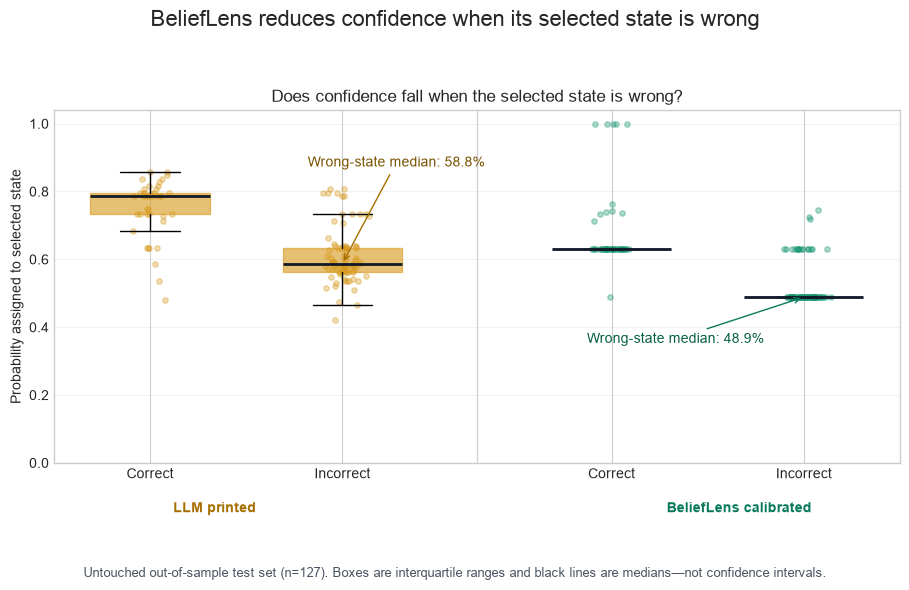

LLM printed accuracy                    0.330709
BeliefLens accuracy                     0.377953
paired accuracy gain                    0.047244
bootstrap CI lower                      0.000000
bootstrap CI upper                      0.102362
LLM confidence when correct             0.752602
LLM confidence when incorrect           0.609448
BeliefLens confidence when correct      0.679564
BeliefLens confidence when incorrect    0.524673
dtype: float64

In [8]:
choice=test.direct_choice_index.to_numpy(int); valid=choice<3
rows=np.arange(len(test)); support=np.full(len(test),np.nan); support[valid]=calibrated[rows[valid],choice[valid]]
printed_class=np.argmax(printed,axis=1); calibrated_class=np.argmax(calibrated,axis=1)
printed_correct=printed_class==ref; calibrated_correct=calibrated_class==ref
printed_error=1-printed_correct.mean(); calibrated_error=1-calibrated_correct.mean()
paired_gain=calibrated_correct.astype(int)-printed_correct.astype(int)
rng=np.random.default_rng(20260827)
gain_boot=np.mean(paired_gain[rng.integers(0,len(test),(10000,len(test)))],axis=1)
gain_ci=np.quantile(gain_boot,[.025,.975])
fig,ax=plt.subplots(figsize=(9.2,5.8))
confidence_groups=[printed_confidence[printed_correct],printed_confidence[~printed_correct],calibrated_confidence[calibrated_correct],calibrated_confidence[~calibrated_correct]]
positions=[0,1,2.4,3.4]; colors=['#D79A1E','#D79A1E','#159570','#159570']
box=ax.boxplot(confidence_groups,positions=positions,widths=.62,patch_artist=True,showfliers=False,medianprops=dict(color='#111827',linewidth=2))
for patch,color in zip(box['boxes'],colors): patch.set(facecolor=color,alpha=.62,edgecolor=color)
for pos,values,color in zip(positions,confidence_groups,colors):
    jitter=rng.normal(0,.055,len(values)); ax.scatter(pos+jitter,values,s=15,color=color,alpha=.35,zorder=1)
ax.set(xticks=positions,xticklabels=['Correct','Incorrect','Correct','Incorrect'],ylabel='Probability assigned to selected state',ylim=(0,1.04),title='Does confidence fall when the selected state is wrong?')
ax.text(.19,-.14,'LLM printed',transform=ax.transAxes,ha='center',color='#A66F00',fontweight='bold')
ax.text(.81,-.14,'BeliefLens calibrated',transform=ax.transAxes,ha='center',color='#087A5B',fontweight='bold')
ax.axvline(1.7,color='#D1D5DB',lw=1); ax.grid(axis='y',alpha=.25)
ax.annotate(f'Wrong-state median: {np.median(printed_confidence[~printed_correct]):.1%}',xy=(1,np.median(printed_confidence[~printed_correct])),xytext=(.30,.84),textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color='#A66F00'),color='#7A5200',fontsize=10)
ax.annotate(f'Wrong-state median: {np.median(calibrated_confidence[~calibrated_correct]):.1%}',xy=(3.4,np.median(calibrated_confidence[~calibrated_correct])),xytext=(.63,.34),textcoords='axes fraction',arrowprops=dict(arrowstyle='->',color='#087A5B'),color='#065F46',fontsize=10)
fig.suptitle('BeliefLens reduces confidence when its selected state is wrong',fontsize=16,y=.99)
fig.text(.5,.012,'Untouched out-of-sample test set (n=127). Boxes are interquartile ranges and black lines are medians—not confidence intervals.',ha='center',fontsize=9.5,color='#4B5563')
fig.tight_layout(rect=(0,.07,1,.94)); fig.savefig(FIG/'04_categorical_reliability_and_confidence.png',dpi=180,bbox_inches='tight'); fig.savefig(FIG/'04_distributional_recovery_and_prompt_stability.png',dpi=180,bbox_inches='tight'); fig.savefig(FIG/'04_printed_confidence_vs_calibrated_support.png',dpi=180,bbox_inches='tight'); plt.show()
pd.Series({'LLM printed accuracy':printed_correct.mean(),'BeliefLens accuracy':calibrated_correct.mean(),'paired accuracy gain':paired_gain.mean(),'bootstrap CI lower':gain_ci[0],'bootstrap CI upper':gain_ci[1],'LLM confidence when correct':printed_confidence[printed_correct].mean(),'LLM confidence when incorrect':printed_confidence[~printed_correct].mean(),'BeliefLens confidence when correct':calibrated_confidence[calibrated_correct].mean(),'BeliefLens confidence when incorrect':calibrated_confidence[~calibrated_correct].mean()}).round(6)

## 5. BeliefLens does something: an auditable intervention

Normal allocation is **P(Risk-on) + 0.5 P(Mixed)**. Intervene when the generated response receives less than 50% calibrated support. Intervention falls back to 50/50 SPY–SGOV. The conformal allocation range is displayed separately: in this experiment it is too broad to support a selective 50-percentage-point certificate, which is itself an important diagnostic.

The threshold and fallback are declared without examining subsequent returns. This is an illustrative governance policy—not an optimized trading rule.

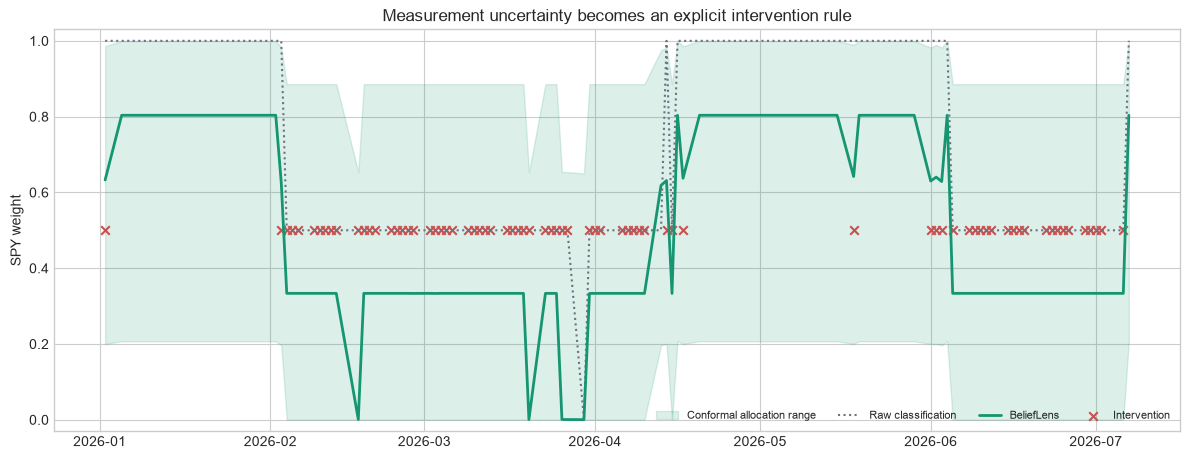

interventions                   74.000
observations                   127.000
intervention rate                0.583
mean allocation-range width      0.832
dtype: float64

In [9]:
def alloc_range(p,r,N=141):
    z=[]
    for i in range(N):
        a=i/(N-1)
        for j in range(N-i):
            b=j/(N-1); q=np.array([a,b,1-a-b])
            if js(q,p)<=r+1e-12: z.append(a+.5*b)
    return min(z),max(z)
ab=np.array([alloc_range(p,radius) for p in calibrated]); width=ab[:,1]-ab[:,0]
intervene=np.nan_to_num(support,nan=0.0)<.50
raw_w=np.where(choice==0,1,np.where(choice==1,.5,0)); printed_w=printed[:,0]+.5*printed[:,1]
bl_w=calibrated[:,0]+.5*calibrated[:,1]; governed_w=np.where(intervene,.5,bl_w)
fig,ax=plt.subplots(figsize=(12,4.7))
ax.fill_between(test.date,ab[:,0],ab[:,1],color=COLORS['Risk-on'],alpha=.15,label='Conformal allocation range')
ax.plot(test.date,raw_w,color='#6B7280',ls=':',label='Raw classification')
ax.plot(test.date,bl_w,color=COLORS['Risk-on'],lw=2,label='BeliefLens')
ax.scatter(test.date[intervene],governed_w[intervene],marker='x',s=38,color=COLORS['Risk-off'],label='Intervention')
ax.set(ylim=(-.03,1.03),ylabel='SPY weight',title='Measurement uncertainty becomes an explicit intervention rule')
ax.legend(ncol=4,fontsize=8); fig.tight_layout(); fig.savefig(FIG/'05_interventions.png',dpi=180,bbox_inches='tight'); plt.show()
pd.Series({'interventions':intervene.sum(),'observations':len(test),'intervention rate':intervene.mean(),'mean allocation-range width':width.mean()}).round(3)

## 6. Loss and 90% CVaR, with and without BeliefLens

Loss is minus realized daily portfolio return. CVaR is mean loss in the worst 10% of observations. This is descriptive held-out evidence, not proof that the illustrative intervention policy is optimal.

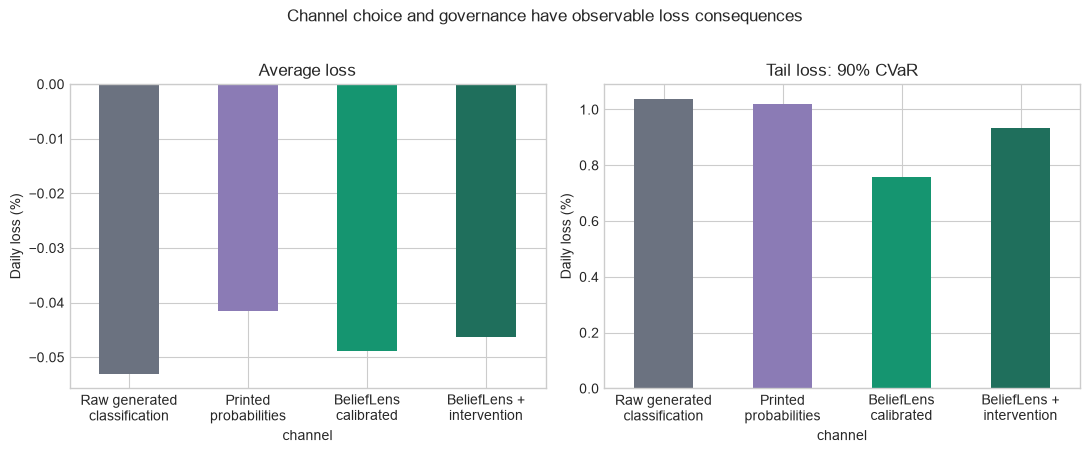

,Mean loss (%),90% VaR (%),90% CVaR (%),Maximum loss (%)
channel,,,,
Raw generated\nclassification,-0.053,0.677,1.039,2.581
Printed\nprobabilities,-0.041,0.661,1.019,2.183
BeliefLens\ncalibrated,-0.049,0.438,0.756,2.077
BeliefLens +\nintervention,-0.046,0.629,0.933,2.083


In [10]:
spy=test.portfolio_spy_return.to_numpy(); safe=test.portfolio_safe_return.to_numpy()
def returns(w):
    turn=np.abs(np.diff(w,prepend=w[0])); return w*spy+(1-w)*safe-turn*.0005
def cvar(loss,a=.9):
    cut=np.quantile(loss,a); return loss[loss>=cut].mean()
W={'Raw generated\nclassification':raw_w,'Printed\nprobabilities':printed_w,'BeliefLens\ncalibrated':bl_w,'BeliefLens +\nintervention':governed_w}
rows=[]
for name,w in W.items():
    loss=-returns(w); rows.append([name,loss.mean(),np.quantile(loss,.9),cvar(loss),loss.max()])
losses=pd.DataFrame(rows,columns=['channel','Mean loss','90% VaR','90% CVaR','Maximum loss']).set_index('channel')
fig,axs=plt.subplots(1,2,figsize=(11,4.4))
for ax,col,title in zip(axs,['Mean loss','90% CVaR'],['Average loss','Tail loss: 90% CVaR']):
    losses[col].mul(100).plot.bar(ax=ax,color=['#6B7280','#8B7BB5','#159570','#1F6F5C']); ax.set(title=title,ylabel='Daily loss (%)'); ax.tick_params(axis='x',rotation=0)
fig.suptitle('Channel choice and governance have observable loss consequences',y=1.02)
fig.tight_layout(); fig.savefig(FIG/'06_loss_cvar.png',dpi=180,bbox_inches='tight'); plt.show()
losses.mul(100).round(3).rename(columns=lambda x:x+' (%)')

## 7. Conclusion and limitation

**What the archived study demonstrates**

- The generated classification, printed probability and continuation law are distinct channels.
- Printed probabilities can disagree materially with calibrated semantic-state probabilities.
- BeliefLens identifies generated answers with weak calibrated support.
- Conformal uncertainty can drive a prespecified accept/warn/intervene decision.
- The measurement choice has observable held-out loss and tail-loss consequences.

**What it does not yet demonstrate**

Each date has a fresh, one-shot language measurement. Dates are sequential, but this notebook does not implement a recursive Bayesian filter or estimate state-transition dynamics. It demonstrates repeated runtime measurement and governance—not a fully dynamic belief process.

The next study should freeze a transition model and compare intervention timing, false alarms, detection delay and sequential CVaR against this one-shot procedure.

In [11]:
print('Figures:',FIG)
sorted(p.name for p in FIG.glob('*.png'))

Figures: /Users/matthewdixon_1/Downloads/codex-workspace/papers/BeliefLens-RSS-Reproducibility/examples/notebooks/finance/assets/spy_governance_story


['01_four_channels.png',
 '01c_historical_evidence.png',
 '01d_raw_prompt_instability.png',
 '01e_calibrated_prompt_stability.png',
 '02_printed_vs_calibrated.png',
 '03_reference_recovery.png',
 '04_categorical_reliability_and_confidence.png',
 '04_distributional_recovery_and_prompt_stability.png',
 '04_printed_confidence_vs_calibrated_support.png',
 '05_interventions.png',
 '06_loss_cvar.png']